# Lab 2 – Poisson Processes on High-Frequency Trade Data

## 0. Data Loading



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.optimize import curve_fit
from scipy.stats import kstest, expon
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

In [3]:
# Helper: convert timestamps to seconds from open
def ts_to_seconds(df, col='ts'):
    df.ts = pd.to_datetime(df.ts)
    t0 = df[col].iloc[0].normalize() + pd.Timedelta(hours=9)
    return (df[col] - t0).dt.total_seconds().values

T_DAY = 8.5 * 3600   
print(f"Trading day length: {T_DAY/3600:.1f} hours = {T_DAY:.0f} seconds")

Trading day length: 8.5 hours = 30600 seconds


In [4]:
trades = np.array([[pd.read_csv(f"Data/stock{i}_day{j}_trades.csv.gz") for i in range(0, 3)] for j in range(0, 5)], dtype=object)
df_trades = pd.concat([df.assign(stock=i, day=j) for (j, i), df in np.ndenumerate(trades)], ignore_index=True)

In [5]:

updates = np.array([[pd.read_csv(f"Data/stock{i}_day{j}_updates.csv.gz") for i in range(0, 3)] for j in range(0, 5)], dtype=object)
df_updates = pd.concat([df_updates.assign(stock=i, day=j) for (j, i), df_updates in np.ndenumerate(updates)], ignore_index=True)

---
## Question 1 – Non-Homogeneous Poisson Process and Trade Times

### 1.1 – Thinning Algorithm

In [1]:
def simulate_nhpp_thinning(intensity_fn, T, lam_star=None, seed=None):
    """
    Simulate a Non-Homogeneous Poisson Process on [0, T] using the thinning algorithm

    Parameters
    ----------
    intensity_fn : callable
        Deterministic intensity function lambda(t) >= 0.
    T : float
        Time horizon.
    lam_star : float or None
        Upper bound on intensity_fn over [0,T].  If None, estimated automatically.
    seed : int or None
        Random seed.

    Returns
    -------
    event_times : np.ndarray
        Sorted array of event times in [0, T].
    """
    rng = np.random.default_rng(seed)
    if lam_star is None:
        t_grid   = np.linspace(0, T, 5000)
        lam_star = float(np.max(intensity_fn(t_grid))) * 1.05  # 5% safety margin
    if lam_star <= 0:
        return np.array([])

    event_times = []
    t = 0.0
    while True:
        s = rng.exponential(1.0 / lam_star)
        t += s
        if t > T:
            break
        if rng.uniform() <= intensity_fn(t) / lam_star:
            event_times.append(t)

    return np.array(event_times)



In [6]:

# Test 1: constant intensity → should recover homogeneous PP
lam_const = 2.0   # events / second
T_test    = 1000.0
N_sim     = 500
counts = [len(simulate_nhpp_thinning(lambda t: lam_const, T_test, seed=i))
          for i in range(N_sim)]
expected_mean = lam_const * T_test
print(f"Test 1 – Constant intensity λ={lam_const}:")
print(f"  Expected count: {expected_mean:.0f}")
print(f"  Simulated mean: {np.mean(counts):.1f} ± {np.std(counts):.1f}")
print(f"  KS test (count ~ Poisson({expected_mean:.0f})): ", end='')
pois_pmf = stats.poisson(expected_mean)
ks = stats.kstest(counts, pois_pmf.cdf)
print(f"p-value = {ks.pvalue:.3f}")

# Test 2: interarrival time-change residuals should be Exp(1)
def lam_ushape(t, T=T_test):
    return 2.0 * (1 + np.exp(-t/200) + np.exp(-(T-t)/200))

ts_sim  = simulate_nhpp_thinning(lam_ushape, T_test, seed=0)

t_grid  = np.linspace(0, T_test, 100000)
lam_grid= lam_ushape(t_grid)
Lambda  = np.cumsum(lam_grid) * (T_test / len(t_grid))
Lambda_fn = lambda s: np.interp(s, t_grid, Lambda)
residuals = np.diff(Lambda_fn(ts_sim))
ks2 = kstest(residuals, 'expon', args=(0, 1))
print(f"\nTest 2 – Time-change residuals ~ Exp(1):")
print(f"  KS p-value = {ks2.pvalue:.3f}  (expect > 0.05 if model is correct)")

Test 1 – Constant intensity λ=2.0:
  Expected count: 2000
  Simulated mean: 2000.4 ± 44.7
  KS test (count ~ Poisson(2000)): p-value = 0.349

Test 2 – Time-change residuals ~ Exp(1):
  KS p-value = 0.430  (expect > 0.05 if model is correct)


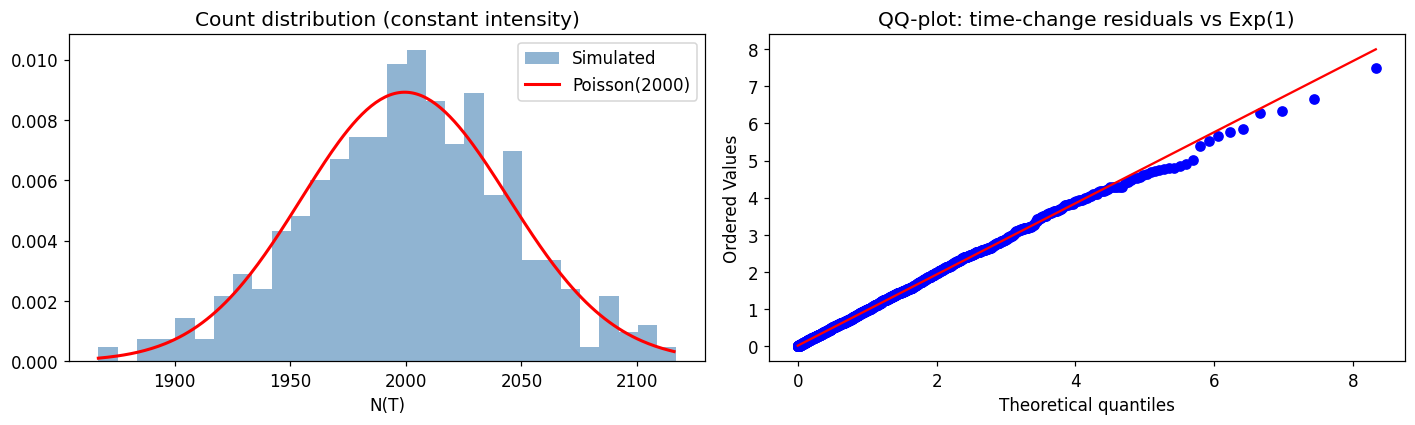

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) Count distribution vs Poisson
ax = axes[0]
ax.hist(counts, bins=30, density=True, alpha=0.6, color='steelblue', label='Simulated')
x_plot = np.arange(int(min(counts)), int(max(counts)))
ax.plot(x_plot, pois_pmf.pmf(x_plot), 'r-', lw=2, label=f'Poisson({expected_mean:.0f})')
ax.set_title('Count distribution (constant intensity)')
ax.set_xlabel('N(T)')
ax.legend()

# (b) QQ-plot of time-change residuals vs Exp(1)
ax = axes[1]
stats.probplot(residuals, dist='expon', plot=ax)
ax.set_title('QQ-plot: time-change residuals vs Exp(1)')

plt.tight_layout()
plt.show()

### 1.2 – Calibration of the Intraday Intensity

We estimate the intraday trade intensity $\lambda(t)$ by binning event times across days and fitting a parametric U-shape model to capture the opening and closing activity peaks.

Using the fitted intensity, we compute the integrated intensity
\[
\Lambda(t) = \int_{0}^{t} \lambda(u)\,du .
\]

By the time-rescaling theorem, if trades follow a non-homogeneous Poisson process with intensity $\lambda(t)$, then the increments
\[
\Lambda(T_k) - \Lambda(T_{k-1})
\]
should be i.i.d.\ $\mathrm{Exp}(1)$.

We assess goodness-of-fit using a Q--Q plot and a Kolmogorov--Smirnov test against the exponential distribution.

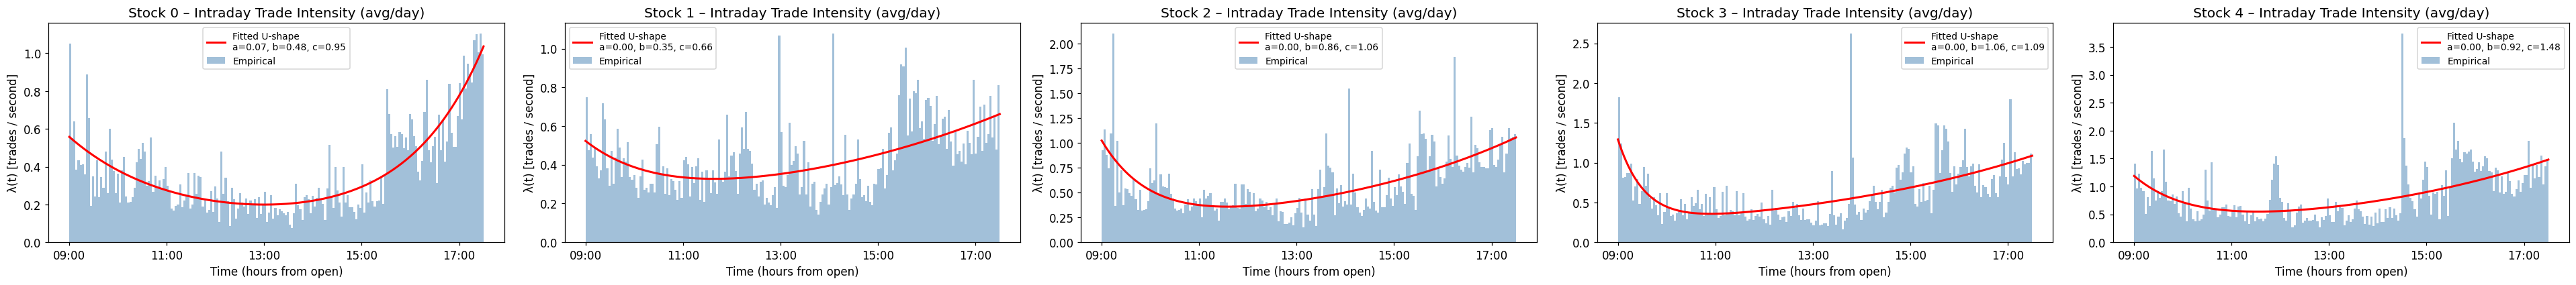

In [9]:

def compute_empirical_intensity(event_times, T, n_bins=200):
    """Estimate λ(t) by binning trade times"""
    counts, edges = np.histogram(event_times, bins=n_bins, range=(0, T))
    bin_width     = T / n_bins
    bin_centers   = 0.5 * (edges[:-1] + edges[1:])
    return bin_centers, counts / bin_width


def aggregate_event_times(stock_idx):
    all_times = []
    for df in trades[stock_idx]:
        t_secs = ts_to_seconds(df)
        t_secs = t_secs[(t_secs >= 0) & (t_secs <= T_DAY)]
        all_times.append(t_secs)
    return np.concatenate(all_times)

def ushape_intensity(t, a, b, c, tau1, tau2):
    """λ(t) = a + b*exp(-t/tau1) + c*exp(-(T-t)/tau2)"""
    return a + b * np.exp(-t / tau1) + c * np.exp(-(T_DAY - t) / tau2)

fig, axes = plt.subplots(1, len(trades), figsize=(7*len(trades), 4), sharey=False)
if len(trades) == 1:
    axes = [axes]

fitted_params = []
for s, ax in enumerate(axes):
    all_times  = aggregate_event_times(s)
    n_days     = len(trades[s])
    t_centers, emp_lam = compute_empirical_intensity(all_times, T_DAY, n_bins=200)
    emp_lam_per_day    = emp_lam / n_days  

    
    try:
        p0     = [emp_lam_per_day.mean(), emp_lam_per_day.max(), emp_lam_per_day.max(),
                  1800, 1800]
        bounds = ([0]*5, [np.inf, np.inf, np.inf, T_DAY, T_DAY])
        popt, _ = curve_fit(ushape_intensity, t_centers, emp_lam_per_day,
                            p0=p0, bounds=bounds, maxfev=10000)
    except RuntimeError:
        popt = p0
    fitted_params.append(popt)

    t_fine    = np.linspace(0, T_DAY, 2000)
    lam_fit   = ushape_intensity(t_fine, *popt)

    t_hours   = t_centers / 3600
    t_fine_h  = t_fine / 3600
    ax.bar(t_hours, emp_lam_per_day, width=(T_DAY/200)/3600,
           alpha=0.5, color='steelblue', label='Empirical')
    ax.plot(t_fine_h, lam_fit, 'r-', lw=2,
            label=f'Fitted U-shape\na={popt[0]:.2f}, b={popt[1]:.2f}, c={popt[2]:.2f}')
    ax.set_title(f'Stock {s} – Intraday Trade Intensity (avg/day)')
    ax.set_xlabel('Time (hours from open)')
    ax.set_ylabel('λ(t) [trades / second]')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x+9):02d}:00'))

plt.tight_layout()
plt.show()

The fitted U-shape intensity successfully captures the main intraday seasonality, with higher activity at market open and close and lower activity around midday for all stocks. Visually, the deterministic model reproduces the overall structure of the empirical intensity.

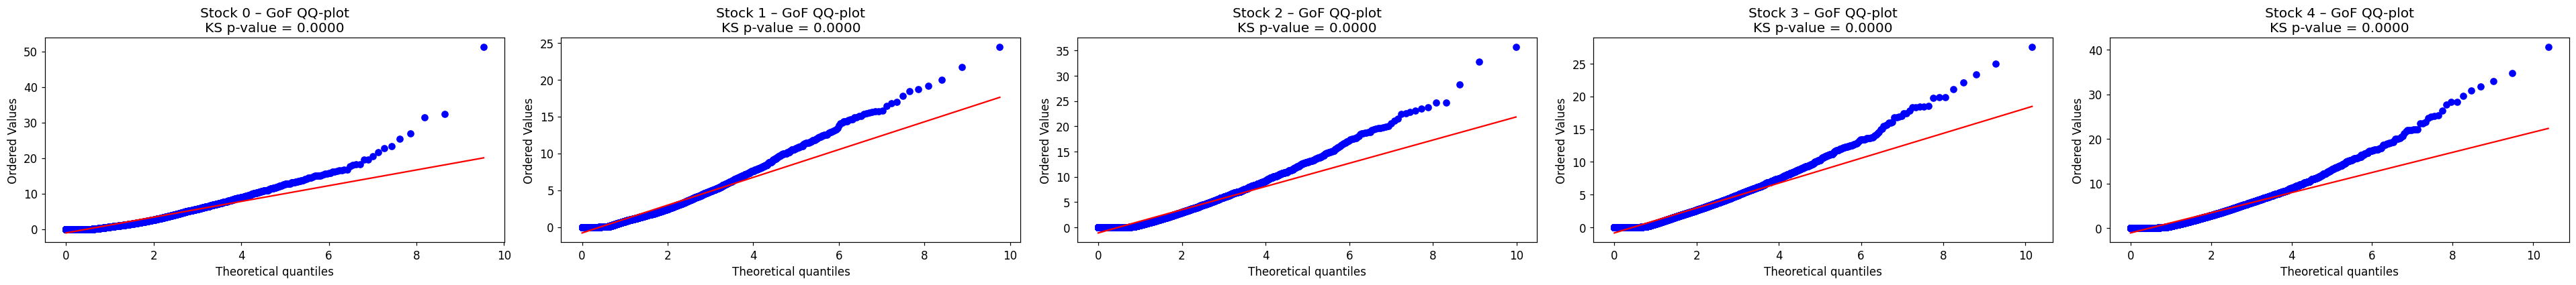

In [10]:
# Under H0: residuals Λ(T_k) - Λ(T_{k-1}) should be iid Exp(1)

def integrated_intensity(t_events, params, T):
    """Numerically integrate fitted λ up to each event time."""
    t_grid  = np.linspace(0, T, 50000)
    lam_g   = ushape_intensity(t_grid, *params)
    Lambda  = np.cumsum(lam_g) * (T / len(t_grid))
    return np.interp(t_events, t_grid, Lambda)

fig, axes = plt.subplots(1, len(trades), figsize=(7*len(trades), 4))
if len(trades) == 1:
    axes = [axes]

for s, ax in enumerate(axes):
   
    df0     = trades[s][0]
    t_secs  = ts_to_seconds(df0)
    t_secs  = np.sort(t_secs[(t_secs > 0) & (t_secs <= T_DAY)])

    Lambda_vals = integrated_intensity(t_secs, fitted_params[s], T_DAY)
    residuals   = np.diff(Lambda_vals)
    residuals   = residuals[residuals > 0]

    ks_stat, ks_p = kstest(residuals, 'expon', args=(0, 1))

    stats.probplot(residuals, dist='expon', plot=ax)
    ax.set_title(f'Stock {s} – GoF QQ-plot\nKS p-value = {ks_p:.4f}')

plt.tight_layout()
plt.show()


However, the goodness-of-fit results clearly reject the NHPP assumption. The Q–Q plots show systematic upward curvature and heavy tails, and the KS test p-values are essentially zero for all stocks. This indicates that the transformed inter-arrival times are not exponentially distributed.

Therefore, while the deterministic intensity λ(t) explains intraday seasonality, it fails to capture trade clustering and overdispersion. The data exhibit dependence and self-excitation effects that a simple non-homogeneous Poisson process cannot model, suggesting that a Hawkes-type process would provide a more appropriate framework.

Just an intutive test 

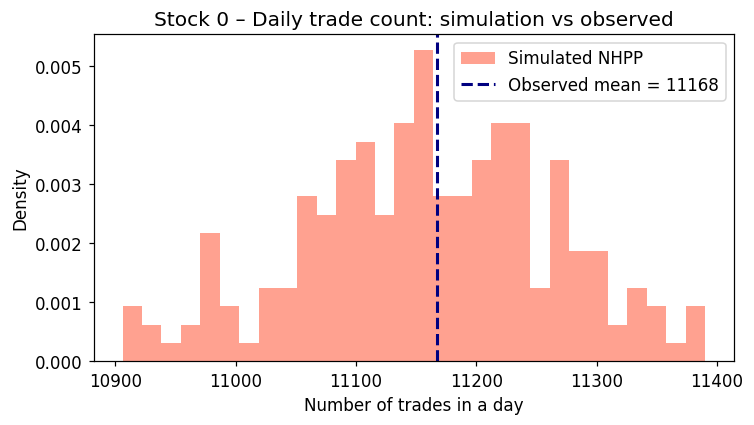

In [12]:
#Simulate NHPP
stock_idx = 0
params    = fitted_params[stock_idx]
intensity_fn = lambda t: ushape_intensity(t, *params)


obs_counts = [len(ts_to_seconds(df)) for df in trades[stock_idx]]


sim_counts = [len(simulate_nhpp_thinning(intensity_fn, T_DAY, seed=i))
              for i in range(200)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sim_counts, bins=30, density=True, alpha=0.6, color='tomato', label='Simulated NHPP')
ax.axvline(np.mean(obs_counts), color='navy', lw=2, linestyle='--',
           label=f'Observed mean = {np.mean(obs_counts):.0f}')
ax.set_xlabel('Number of trades in a day')
ax.set_ylabel('Density')
ax.set_title(f'Stock {stock_idx} – Daily trade count: simulation vs observed')
ax.legend()
plt.tight_layout()
plt.show()

---
## Question 2 – Brownian Motions with Poisson Sampling (Epps Effect)

We consider $p_i(t) = \sigma_i W_i(t)$ with $\langle W_1, W_2 \rangle_t = \rho t$.
Each process is sampled at Poisson times with intensity $\mu_i$.
We compute the standard realized covariance estimator at various sampling periods $\tau$
and observe the **Epps effect**: the estimator shrinks toward 0 for high-frequency sampling.

In [ ]:
def simulate_poisson_sampled_bm(T, sigma1, sigma2, rho, mu1, mu2, n_paths=200, seed=0):
    """
    Simulate bivariate BM observed at independent Poisson times.

    Returns
    -------
    List of (times1, prices1, times2, prices2) tuples.
    """
    rng    = np.random.default_rng(seed)
    paths  = []
    dt_fine = 1e-3         
    n_fine  = int(T / dt_fine)
    t_fine  = np.linspace(0, T, n_fine + 1)

    for _ in range(n_paths):
        # Correlated BM increments
        Z1 = rng.standard_normal(n_fine)
        Z2 = rho * Z1 + np.sqrt(1 - rho**2) * rng.standard_normal(n_fine)
        dW1 = sigma1 * np.sqrt(dt_fine) * Z1
        dW2 = sigma2 * np.sqrt(dt_fine) * Z2
        p1  = np.concatenate([[0], np.cumsum(dW1)])
        p2  = np.concatenate([[0], np.cumsum(dW2)])

        # Independent Poisson observation times
        obs1 = np.sort(rng.uniform(0, T, rng.poisson(mu1 * T)))
        obs2 = np.sort(rng.uniform(0, T, rng.poisson(mu2 * T)))

        # Interpolate BM at observation times
        p1_obs = np.interp(obs1, t_fine, p1)
        p2_obs = np.interp(obs2, t_fine, p2)
        paths.append((obs1, p1_obs, obs2, p2_obs))

    return paths


def realized_covariance(times1, prices1, times2, prices2, tau, T):
    """
    Previous-tick synchronization on a regular grid with spacing tau,
    then compute realized covariance.
    """
    grid   = np.arange(0, T + tau, tau)
    # Previous-tick interpolation
    def prev_tick(obs_t, obs_p, grid):
        idx   = np.searchsorted(obs_t, grid, side='right') - 1
        idx   = np.clip(idx, 0, len(obs_p) - 1)
        return obs_p[idx]

    p1_g  = prev_tick(times1, prices1, grid)
    p2_g  = prev_tick(times2, prices2, grid)
    r1    = np.diff(p1_g)
    r2    = np.diff(p2_g)
    return np.sum(r1 * r2)




True covariance [p1,p2]_T = rho*sigma1*sigma2*T = 0.2520


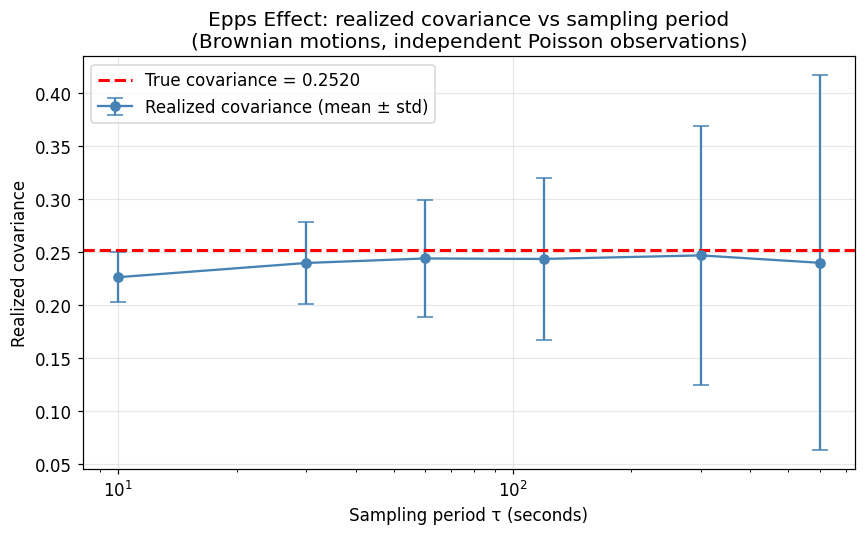


Table:
   tau (s) |    Mean Rcov |        Std |       Bias
------------------------------------------------
        10 |      0.22646 |    0.02353 |   -0.02554
        30 |      0.23988 |    0.03880 |   -0.01212
        60 |      0.24413 |    0.05542 |   -0.00787
       120 |      0.24368 |    0.07643 |   -0.00832
       300 |      0.24701 |    0.12234 |   -0.00499
       600 |      0.24006 |    0.17688 |   -0.01194


In [ ]:
# ── Parameters 
T_BM   = 3600.0    # 1 hour simulation
sigma1 = 0.01
sigma2 = 0.01
rho    = 0.7
mu1    = 1.0      
mu2    = 1.0
N_PATHS = 300
true_cov = rho * sigma1 * sigma2 * T_BM

print(f"True covariance [p1,p2]_T = rho*sigma1*sigma2*T = {true_cov:.4f}")

paths = simulate_poisson_sampled_bm(T_BM, sigma1, sigma2, rho, mu1, mu2,
                                     n_paths=N_PATHS, seed=42)


tau_values = [10, 30, 60, 120, 300, 600]

rcov_means = []
rcov_stds  = []
for tau in tau_values:
    rcovs = [realized_covariance(*p, tau, T_BM) for p in paths]
    rcov_means.append(np.mean(rcovs))
    rcov_stds.append(np.std(rcovs))

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(tau_values, rcov_means, yerr=rcov_stds, fmt='o-',
            color='steelblue', capsize=5, label='Realized covariance (mean ± std)')
ax.axhline(true_cov, color='red', linestyle='--', lw=2, label=f'True covariance = {true_cov:.4f}')
ax.set_xscale('log')
ax.set_xlabel('Sampling period τ (seconds)')
ax.set_ylabel('Realized covariance')
ax.set_title('Epps Effect: realized covariance vs sampling period\n(Brownian motions, independent Poisson observations)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTable:")
print(f"{'tau (s)':>10} | {'Mean Rcov':>12} | {'Std':>10} | {'Bias':>10}")
print('-' * 48)
for tau, m, s in zip(tau_values, rcov_means, rcov_stds):
    print(f"{tau:>10} | {m:>12.5f} | {s:>10.5f} | {m-true_cov:>10.5f}")


Comment on the Epps Effect:
- At large τ (coarse sampling), the realized covariance converges toward the true value.
- At small τ (fine/HF sampling), the estimator is strongly biased downward toward 0.
- This is the Epps effect (1979): when two assets are sampled asynchronously at HF,
  the empirical correlation appears to vanish.
- Cause: at very fine time scales, the probability that both assets trade within the
  same interval goes to 0, so most cross-products are zero.
- The optimal τ trades off bias (too fine) and variance (too coarse).
- Solutions include the Hayashi-Yoshida estimator or pre-averaging methods.


---
## Question 3 – Empirical Intensities and LOB Features

### 3.1 – Trade Intensity vs Queue Size

In [28]:
df_updates['ts'] = pd.to_datetime(df_updates['ts'])
df_updates = df_updates.sort_values(['stock', 'day', 'ts']).reset_index(drop=True)


def build_lob_snapshot_at_trades(df):
    """
    For a single (stock, day) group:
    - Forward-fill bp, bq, ap, aq so each trade row carries the last known LOB state.
    - Keep only type == 'T' rows.
    - Compute spread, queue, dt (seconds since previous trade).
    """
    df = df.copy()
    for col in ['bp', 'bq', 'ap', 'aq']:
        df[col] = df[col].ffill()

    trades = df[df['type'] == 'T'].copy()
    if len(trades) < 2:
        return None

    trades['spread'] = trades['ap'] - trades['bp']
    trades['queue']  = trades['bq'] + trades['aq']

    t_open = trades['ts'].iloc[0].normalize() + pd.Timedelta(hours=9)
    trades['t_sec'] = (trades['ts'] - t_open).dt.total_seconds()
    trades['dt']    = trades['t_sec'].diff()

    trades = trades.dropna(subset=['spread', 'queue', 'dt'])
    trades = trades[(trades['spread'] > 0) & (trades['queue'] > 0) & (trades['dt'] > 0)]
    return trades.reset_index(drop=True)



In [29]:

snapshots = {}
for (s, d), grp in df_updates.groupby(['stock', 'day']):
    snap = build_lob_snapshot_at_trades(grp)
    if snap is not None and len(snap) > 10:
        snapshots[(s, d)] = snap

print(f"Valid (stock, day) pairs: {len(snapshots)}")
stocks = sorted(df_updates['stock'].unique())

Valid (stock, day) pairs: 15


In [30]:

def intensity_vs_feature(df, feature_col, n_bins=10):
    """
    Estimate lambda = 1/E[dt | feature in bin] using quantile bins.
    Returns centers, lambdas, errors (delta method), counts.
    """
    x  = df[feature_col].values
    dt = df['dt'].values

    bin_edges = np.unique(np.quantile(x, np.linspace(0, 1, n_bins + 1)))
    if len(bin_edges) < 3:
        return None, None, None, None

    bin_idx = np.digitize(x, bin_edges[1:-1])
    centers, lambdas, errors, counts = [], [], [], []
    for b in range(len(bin_edges) - 1):
        mask = bin_idx == b
        if mask.sum() < 5:
            continue
        dt_b    = dt[mask]
        mean_dt = dt_b.mean()
        std_dt  = dt_b.std()
        n       = mask.sum()
        centers.append(x[mask].mean())
        lambdas.append(1.0 / mean_dt)
        errors.append(std_dt / (np.sqrt(n) * mean_dt**2))
        counts.append(n)
    return np.array(centers), np.array(lambdas), np.array(errors), np.array(counts)



### Q3.1 – Trade intensity vs queue size

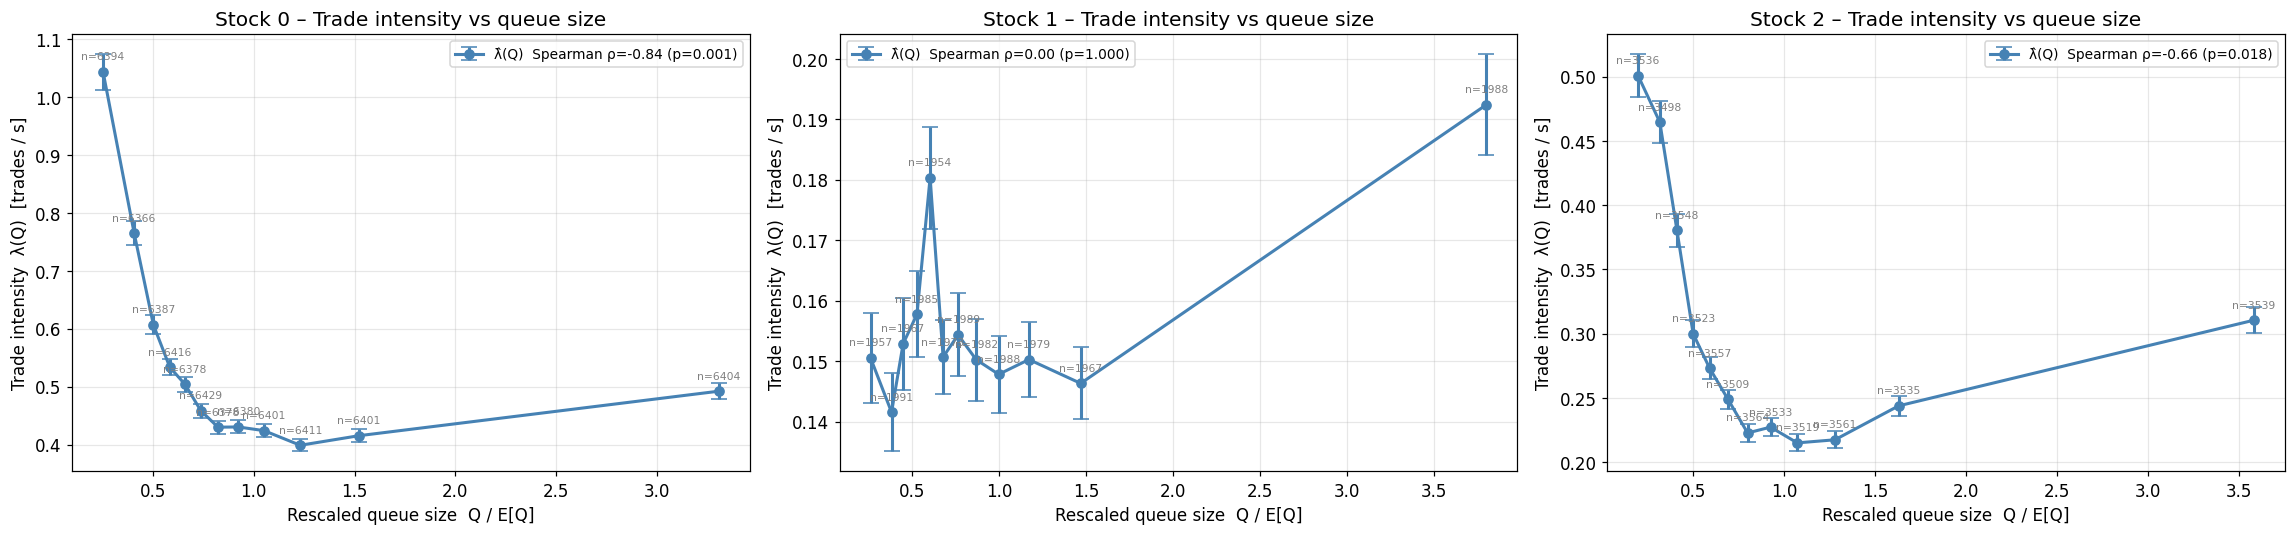

In [31]:

fig, axes = plt.subplots(1, len(stocks), figsize=(7 * len(stocks), 5), squeeze=False)

for col_idx, s in enumerate(stocks):
    ax = axes[0][col_idx]

    days_data = [snapshots[(s, d)] for (ss, d) in snapshots if ss == s]
    if not days_data:
        continue
    stock_df = pd.concat(days_data, ignore_index=True).copy()
    stock_df['queue_scaled'] = stock_df['queue'] / stock_df['queue'].mean()

    centers, lambdas, errors, counts = intensity_vs_feature(stock_df, 'queue_scaled', n_bins=12)
    if centers is None:
        continue

    rho, pval = spearmanr(centers, lambdas)

    ax.errorbar(centers, lambdas, yerr=errors, fmt='o-', color='steelblue',
                capsize=5, linewidth=2, markersize=6,
                label=f'λ̂(Q)  Spearman ρ={rho:.2f} (p={pval:.3f})')
    for cx, lx, n in zip(centers, lambdas, counts):
        ax.annotate(f'n={n}', (cx, lx), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=7, color='gray')

    ax.set_xlabel('Rescaled queue size  Q / E[Q]')
    ax.set_ylabel('Trade intensity  λ(Q)  [trades / s]')
    ax.set_title(f'Stock {s} – Trade intensity vs queue size')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Trade intensity decreases significantly with queue size for Stocks 0 and 2 (strong negative Spearman correlations), indicating that thinner books are associated with higher trading activity, while Stock 1 shows no clear dependence.

The relationship between trade intensity and spread is much weaker and mostly not statistically significant, with only a mild tendency for higher intensity at the smallest spread levels.

Overall, queue size appears to be a more informative LOB feature for explaining trade intensity than spread in this dataset.

### Q3.2 – Trade intensity vs spread

In [ ]:
days_data = [snapshots[(0, d)] for (ss, d) in snapshots if ss == 00]

stock_df = pd.concat(days_data, ignore_index=True).copy()


tick = stock_df['spread'][stock_df['spread'] > 0].quantile(0.05)
stock_df['spread_ticks'] = stock_df['spread'] / tick

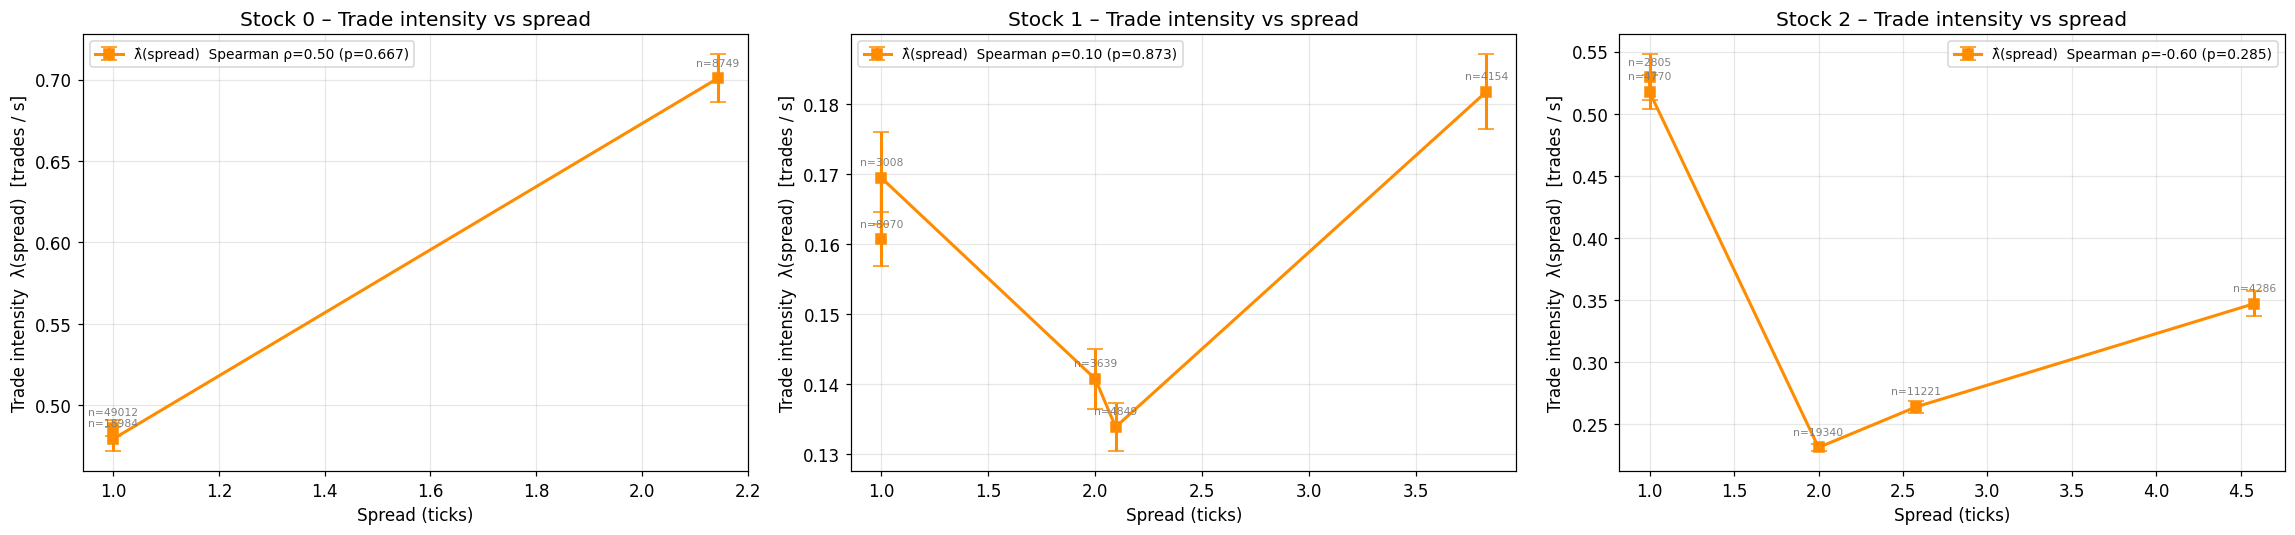

In [32]:


fig, axes = plt.subplots(1, len(stocks), figsize=(7 * len(stocks), 5), squeeze=False)

for col_idx, s in enumerate(stocks):
    ax = axes[0][col_idx]

    days_data = [snapshots[(s, d)] for (ss, d) in snapshots if ss == s]
    if not days_data:
        continue
    stock_df = pd.concat(days_data, ignore_index=True).copy()

    # Express spread in ticks
    tick = stock_df['spread'][stock_df['spread'] > 0].quantile(0.05)
    stock_df['spread_ticks'] = stock_df['spread'] / tick

    centers, lambdas, errors, counts = intensity_vs_feature(stock_df, 'spread_ticks', n_bins=10)
    if centers is None:
        continue

    rho, pval = spearmanr(centers, lambdas)

    ax.errorbar(centers, lambdas, yerr=errors, fmt='s-', color='darkorange',
                capsize=5, linewidth=2, markersize=6,
                label=f'λ̂(spread)  Spearman ρ={rho:.2f} (p={pval:.3f})')
    for cx, lx, n in zip(centers, lambdas, counts):
        ax.annotate(f'n={n}', (cx, lx), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=7, color='gray')

    ax.set_xlabel('Spread (ticks)')
    ax.set_ylabel('Trade intensity  λ(spread)  [trades / s]')
    ax.set_title(f'Stock {s} – Trade intensity vs spread')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


